In [ ]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap

# =========================
# R1:  Define risk
# =========================
HEX_GRID_PATH = "data/hex_grid_model1.geojson"
ROADS_PATH    = "data/roads.geojson"   # optional
GATES_PATH    = "data/gates.geojson"   # optional
CAMPS_PATH    = "data/camps.geojson"   # optional
OUTPUT_PATH   = "Figure1_Normalized_Components_SCI.png"

PERIOD_LABEL = "Representative period"

plt.rcParams.update({
    "font.family": "DejaVu Serif",   # replace with Times New Roman if installed
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

# SCI cool-tone colormap
SCI_COOL = LinearSegmentedColormap.from_list(
    "sci_cool",
    ["#eef6fb", "#c9e6f2", "#8cc9de", "#4ea6c8", "#1e6f9f", "#124e78"]
)

PAN_MASK_COLOR = "#eef3f8"
ROAD_COLOR = "#9fb3c8"
GATE_COLOR = "#1f4e79"
CAMP_COLOR = "#2a9d8f"
EDGE_COLOR = "#d9dde3"


def load_optional_layer(path):
    if path is None or not os.path.exists(path):
        return None
    return gpd.read_file(path)


def setup_map_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(False)


def overlay_base_layers(ax, roads=None, gates=None, camps=None):
    if roads is not None and len(roads) > 0:
        roads.plot(ax=ax, color=ROAD_COLOR, linewidth=0.55, alpha=0.70, zorder=3)

    if gates is not None and len(gates) > 0:
        gates.plot(ax=ax, color=GATE_COLOR, markersize=28, marker="^",
                   edgecolor="white", linewidth=0.5, zorder=4)

    if camps is not None and len(camps) > 0:
        camps.plot(ax=ax, color=CAMP_COLOR, markersize=24, marker="s",
                   edgecolor="white", linewidth=0.5, zorder=4)


def mask_pan_core_values(gdf, value_col, pan_col="is_pan_core"):
    vals = gdf[value_col].copy()
    if pan_col in gdf.columns:
        vals = vals.where(~gdf[pan_col].astype(bool), np.nan)
    return vals


def plot_figure1():
    hex_gdf = gpd.read_file(HEX_GRID_PATH)
    roads = load_optional_layer(ROADS_PATH)
    gates = load_optional_layer(GATES_PATH)
    camps = load_optional_layer(CAMPS_PATH)

    required_cols = ["A_norm", "T_norm", "E_norm", "S_norm", "is_pan_core"]
    missing = [c for c in required_cols if c not in hex_gdf.columns]
    if missing:
        raise ValueError(f"Missing columns in hex grid file: {missing}")

    fig, axes = plt.subplots(2, 2, figsize=(13.2, 10.2))
    axes = axes.flatten()

    components = [
        ("A_norm", r"Asset value $A_i(t^*)$"),
        ("T_norm", r"Threat intensity $T_i(t^*)$"),
        ("E_norm", r"Exposure/accessibility $E_i(t^*)$"),
        ("S_norm", r"Seasonal amplification $S_i(t^*)$")
    ]

    last_mappable = None

    for ax, (col, subtitle) in zip(axes, components):
        tmp = hex_gdf.copy()
        tmp["_plot"] = mask_pan_core_values(hex_gdf, col, pan_col="is_pan_core")

        hex_gdf.boundary.plot(ax=ax, color=EDGE_COLOR, linewidth=0.16, zorder=1)
        tmp.plot(
            ax=ax,
            column="_plot",
            cmap=SCI_COOL,
            vmin=0,
            vmax=1,
            linewidth=0.16,
            edgecolor=EDGE_COLOR,
            zorder=2,
            missing_kwds={"color": PAN_MASK_COLOR}
        )

        overlay_base_layers(ax, roads=roads, gates=gates, camps=camps)
        setup_map_axis(ax)
        ax.set_title(subtitle, pad=8, color="#1f2d3d")
        last_mappable = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=SCI_COOL)

    fig.suptitle("Normalized Spatial Components of Vulnerability",
                 y=0.985, fontsize=16, color="#16324f", fontweight="bold")
    cbar = fig.colorbar(last_mappable, ax=axes, fraction=0.028, pad=0.02, shrink=0.94)
    cbar.set_label("Normalized value", color="#16324f")
    cbar.ax.tick_params(colors="#16324f")

    fig.text(0.5, 0.02, f"Representative period: {PERIOD_LABEL}",
             ha="center", va="center", fontsize=11, color="#4a6178")

    fig.savefig(OUTPUT_PATH, bbox_inches="tight", facecolor="white")
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    plot_figure1()

In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap

# =========================
# R1: 
# =========================
HEX_GRID_PATH = "data/hex_grid_model1.geojson"
ROADS_PATH    = "data/roads.geojson"
GATES_PATH    = "data/gates.geojson"
CAMPS_PATH    = "data/camps.geojson"
WEIGHTS_CSV   = "data/entropy_weights.csv"
OUTPUT_PATH   = "Figure2_DVI_and_Weights_SCI.png"

PERIOD_LABEL = "Representative Month"

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

SCI_COOL_DVI = LinearSegmentedColormap.from_list(
    "sci_cool_dvi",
    ["#f4fbff", "#d9eff7", "#a7d8e8", "#6ab8d6", "#2b8cbe", "#0f5b8d", "#08306b"]
)

PAN_MASK_COLOR = "#eef3f8"
ROAD_COLOR = "#9fb3c8"
GATE_COLOR = "#1f4e79"
CAMP_COLOR = "#2a9d8f"
EDGE_COLOR = "#d9dde3"


def load_optional_layer(path):
    if path is None or not os.path.exists(path):
        return None
    return gpd.read_file(path)


def setup_map_axis(ax):
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    for spine in ax.spines.values():
        spine.set_visible(False)


def overlay_base_layers(ax, roads=None, gates=None, camps=None):
    if roads is not None and len(roads) > 0:
        roads.plot(ax=ax, color=ROAD_COLOR, linewidth=0.55, alpha=0.70, zorder=3)
    if gates is not None and len(gates) > 0:
        gates.plot(ax=ax, color=GATE_COLOR, markersize=28, marker="^",
                   edgecolor="white", linewidth=0.5, zorder=4)
    if camps is not None and len(camps) > 0:
        camps.plot(ax=ax, color=CAMP_COLOR, markersize=24, marker="s",
                   edgecolor="white", linewidth=0.5, zorder=4)


def mask_pan_core_values(gdf, value_col, pan_col="is_pan_core"):
    vals = gdf[value_col].copy()
    if pan_col in gdf.columns:
        vals = vals.where(~gdf[pan_col].astype(bool), pd.NA)
    return vals


def plot_figure2():
    hex_gdf = gpd.read_file(HEX_GRID_PATH)
    weights_df = pd.read_csv(WEIGHTS_CSV)

    roads = load_optional_layer(ROADS_PATH)
    gates = load_optional_layer(GATES_PATH)
    camps = load_optional_layer(CAMPS_PATH)

    row = weights_df.loc[weights_df["period"] == PERIOD_LABEL]
    if row.empty:
        raise ValueError(f"No row found where period == '{PERIOD_LABEL}'")
    row = row.iloc[0]

    fig = plt.figure(figsize=(13.2, 7.6))
    gs = fig.add_gridspec(1, 2, width_ratios=[2.2, 1.0], wspace=0.10)

    ax_map = fig.add_subplot(gs[0, 0])
    ax_bar = fig.add_subplot(gs[0, 1])

    tmp = hex_gdf.copy()
    tmp["_plot"] = mask_pan_core_values(hex_gdf, "DVI", pan_col="is_pan_core")

    hex_gdf.boundary.plot(ax=ax_map, color=EDGE_COLOR, linewidth=0.16, zorder=1)
    tmp.plot(
        ax=ax_map,
        column="_plot",
        cmap=SCI_COOL_DVI,
        vmin=0,
        vmax=1,
        linewidth=0.16,
        edgecolor=EDGE_COLOR,
        zorder=2,
        missing_kwds={"color": PAN_MASK_COLOR}
    )

    overlay_base_layers(ax_map, roads=roads, gates=gates, camps=camps)
    setup_map_axis(ax_map)
    ax_map.set_title(r"Dynamic Vulnerability Index $DVI_i(t^*)$", pad=10, color="#1f2d3d")

    sm = plt.cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=SCI_COOL_DVI)
    cbar = fig.colorbar(sm, ax=ax_map, fraction=0.045, pad=0.02)
    cbar.set_label("DVI", color="#16324f")
    cbar.ax.tick_params(colors="#16324f")

    labels = [r"$w_A(t^*)$", r"$w_T(t^*)$", r"$w_E(t^*)$", r"$w_S(t^*)$"]
    values = [row["w_A"], row["w_T"], row["w_E"], row["w_S"]]
    colors = ["#0f5b8d", "#2b8cbe", "#4ea6c8", "#7bc8d6"]

    bars = ax_bar.bar(labels, values, color=colors, edgecolor="#335c67", linewidth=0.6, width=0.62)
    ax_bar.set_ylim(0, max(0.4, max(values) * 1.22))
    ax_bar.set_ylabel("Entropy-based weight", color="#16324f")
    ax_bar.set_title("Weights for the same period", pad=10, color="#1f2d3d")
    ax_bar.grid(axis="y", linestyle="--", alpha=0.28, color="#9fb3c8")
    ax_bar.tick_params(colors="#16324f")
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.spines["left"].set_color("#aab7c4")
    ax_bar.spines["bottom"].set_color("#aab7c4")

    for bar in bars:
        h = bar.get_height()
        ax_bar.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=9, color="#274c77")

    fig.suptitle("Dynamic Vulnerability Index and Entropy-Based Weights",
                 y=0.985, fontsize=16, color="#16324f", fontweight="bold")
    fig.text(0.5, 0.02, f"Representative period: {PERIOD_LABEL}",
             ha="center", va="center", fontsize=11, color="#4a6178")

    fig.savefig(OUTPUT_PATH, bbox_inches="tight", facecolor="white")
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    plot_figure2()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# =========================
# User settings
# =========================
OUTPUT_PATH = "Figure3_Protection_Supply_Mechanism_SCI.png"

T_MAX = 1.0
BETA = 1.2

plt.rcParams.update({
    "font.family": "DejaVu Serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "figure.dpi": 180,
    "savefig.dpi": 400,
    "axes.facecolor": "white",
    "figure.facecolor": "white"
})

SCI_TECH = LinearSegmentedColormap.from_list(
    "sci_tech",
    ["#f7fcfd", "#d9f0f0", "#a6dcd5", "#5ab4ac", "#2b8cbe", "#22577a", "#16324f"]
)

LINE_BLUE = "#1d6996"
FILL_BLUE = "#7bc8d6"
REFERENCE_RED = "#b23a48"
TEXT_DARK = "#16324f"


def plot_figure3(T_max=T_MAX, b=BETA):
    fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.4), gridspec_kw={"wspace": 0.28})

    # Panel (a): patrol saturation
    ax1 = axes[0]
    e = np.linspace(0, 5, 400)
    g_pat = 1 - np.exp(-b * e)

    ax1.plot(e, g_pat, color=LINE_BLUE, linewidth=2.5)
    ax1.fill_between(e, 0, g_pat, color=FILL_BLUE, alpha=0.25)
    ax1.set_xlim(0, 5)
    ax1.set_ylim(0, 1.02)
    ax1.set_xlabel(r"Patrol effort $e_i(t)$", color=TEXT_DARK)
    ax1.set_ylabel(r"$g_i^{pat}(t)$", color=TEXT_DARK)
    ax1.set_title(r"(a) Patrol saturation", color=TEXT_DARK, pad=8)
    ax1.grid(True, linestyle="--", alpha=0.25, color="#a7bed3")
    ax1.tick_params(colors=TEXT_DARK)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_color("#aab7c4")
    ax1.spines["bottom"].set_color("#aab7c4")

    # Panel (b): technology-response coupling
    ax2 = axes[1]
    t = np.linspace(0, 3 * T_max, 240)
    p_det = np.linspace(0, 1, 240)
    T, P = np.meshgrid(t, p_det)
    Gtech = P * np.exp(-T / T_max)

    im = ax2.contourf(T, P, Gtech, levels=40, cmap=SCI_TECH)
    contour = ax2.contour(T, P, Gtech, levels=8, colors="white", linewidths=0.45, alpha=0.75)
    ax2.clabel(contour, inline=True, fontsize=8, fmt="%.2f")

    ax2.axvline(T_max, color=REFERENCE_RED, linestyle="--", linewidth=1.8,
                label=r"Reference scale $T_{\max}$")
    ax2.set_xlim(0, 3 * T_max)
    ax2.set_ylim(0, 1)
    ax2.set_xlabel(r"Response time $t_i(t)$", color=TEXT_DARK)
    ax2.set_ylabel(r"Detection probability $p_i^{det}(t)$", color=TEXT_DARK)
    ax2.set_title(r"(b) Technology-response coupling", color=TEXT_DARK, pad=8)
    ax2.tick_params(colors=TEXT_DARK)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["left"].set_color("#aab7c4")
    ax2.spines["bottom"].set_color("#aab7c4")
    ax2.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#d0d7de")

    cbar = fig.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    cbar.set_label(r"$g_i^{tech}(t)$", color=TEXT_DARK)
    cbar.ax.tick_params(colors=TEXT_DARK)

    fig.suptitle("Protection Supply Mechanism in Model 1",
                 y=0.985, fontsize=16, color=TEXT_DARK, fontweight="bold")

    fig.savefig(OUTPUT_PATH, bbox_inches="tight", facecolor="white")
    print(f"Saved: {OUTPUT_PATH}")


if __name__ == "__main__":
    plot_figure3()

<>:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_3565/1299228158.py:98: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.plot(budgets, expected_P, color=COLOR_LINE1, linewidth=2.5, label='Expected Protection $\mathbb{E}[P(t)]$')


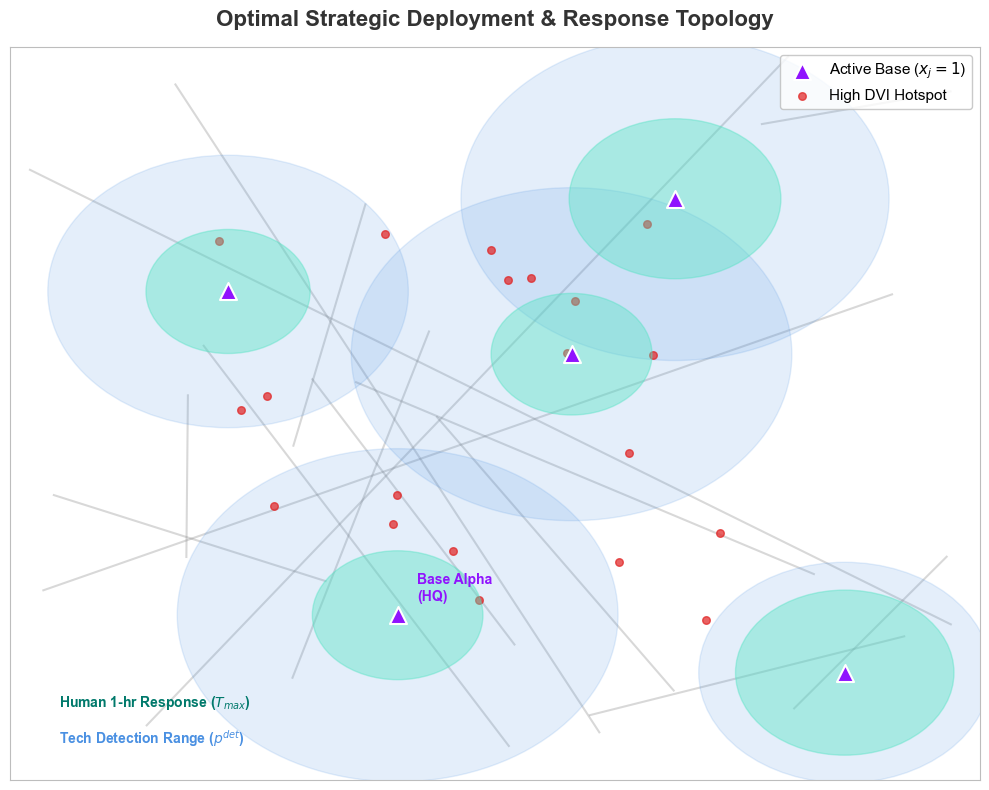

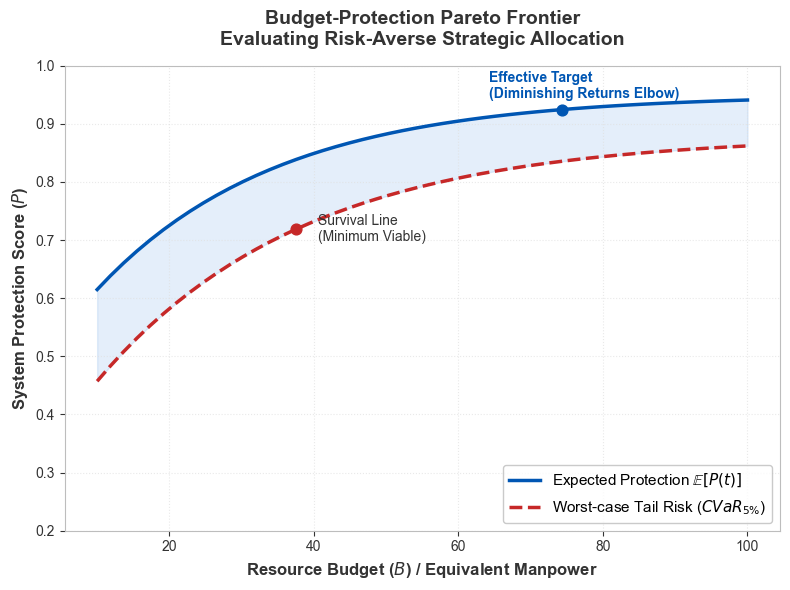

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =====================================================================
# 通用设置：SCI 白底学术风格 (Nature/Science Style)
# =====================================================================
plt.style.use('default')
COLOR_BG = '#FFFFFF'          # 纯白背景
COLOR_GRID = '#E0E0E0'        # 浅灰网格线
COLOR_TEXT = '#333333'        # 深灰字体(比纯黑看起来更高级)

# 学术对比配色 (深蓝、青绿、紫、酒红)
COLOR_TECH = '#4A90E2'        # 科技覆盖圈 - 柔和蓝
COLOR_PATROL = '#50E3C2'      # 人力覆盖圈 - 青绿色
COLOR_BASE = '#9013FE'        # 基地节点 - 紫色
COLOR_HOTSPOT = '#E02020'     # 危险热点 - 红色
COLOR_LINE1 = '#0056b3'       # 期望曲线 - 深海蓝
COLOR_LINE2 = '#c62828'       # 最坏底线 - 酒红

plt.rcParams.update({
    'figure.facecolor': COLOR_BG,
    'axes.facecolor': COLOR_BG,
    'axes.edgecolor': '#BDBDBD',
    'axes.labelcolor': COLOR_TEXT,
    'xtick.color': COLOR_TEXT,
    'ytick.color': COLOR_TEXT,
    'grid.color': COLOR_GRID,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans']
})

# =====================================================================
# Figure 1: 人机协同空间部署拓扑图 (白底版)
# =====================================================================
np.random.seed(42)
fig, ax = plt.subplots(figsize=(10, 8))

# 伪造基站数据
n_bases = 5
base_x = np.random.uniform(10, 90, n_bases)
base_y = np.random.uniform(10, 90, n_bases)

# 绘制路网阻力线 (浅灰色)
for _ in range(15):
    x_line = np.random.uniform(0, 100, 2)
    y_line = np.random.uniform(0, 100, 2)
    ax.plot(x_line, y_line, color='grey', alpha=0.3, linewidth=1.5, zorder=1)

# 绘制覆盖圈
for i in range(n_bases):
    # 技术预警圈 (大圆，浅蓝色)
    circle_tech = plt.Circle((base_x[i], base_y[i]), radius=np.random.uniform(15, 25), 
                             color=COLOR_TECH, alpha=0.15, zorder=2)
    # 人力 1 小时响应圈 (小圆，青绿色)
    circle_patrol = plt.Circle((base_x[i], base_y[i]), radius=np.random.uniform(8, 12), 
                               color=COLOR_PATROL, alpha=0.4, zorder=3)
    ax.add_patch(circle_tech)
    ax.add_patch(circle_patrol)
    
    # 基地位置 (紫色三角形)
    ax.scatter(base_x[i], base_y[i], color=COLOR_BASE, s=150, marker='^', 
               edgecolors='white', linewidth=1.5, zorder=4, label='Active Base ($x_j=1$)' if i==0 else "")

# 绘制高危热点 (红色散点)
hx = np.random.uniform(20, 80, 20)
hy = np.random.uniform(20, 80, 20)
ax.scatter(hx, hy, color=COLOR_HOTSPOT, s=30, alpha=0.7, zorder=2, label='High DVI Hotspot')

# 细节修饰
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Optimal Strategic Deployment & Response Topology', fontsize=16, color=COLOR_TEXT, pad=15, fontweight='bold')
ax.legend(loc='upper right', frameon=True, facecolor=COLOR_BG, edgecolor='#BDBDBD', fontsize=11)

# 文本标注
ax.text(base_x[0]+2, base_y[0]+2, 'Base Alpha\n(HQ)', color=COLOR_BASE, fontsize=10, fontweight='bold')
ax.text(5, 5, 'Tech Detection Range ($p^{det}$)', color=COLOR_TECH, fontsize=10, fontweight='bold')
ax.text(5, 10, 'Human 1-hr Response ($T_{max}$)', color='#00796B', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('Model2_Deployment_Map_Light.pdf', dpi=300)
plt.show()

# =====================================================================
# Figure 2: 预算-保护前沿曲线 Pareto Frontier (白底版)
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# 伪造数据
budgets = np.linspace(10, 100, 50)
expected_P = 0.95 - 0.5 * np.exp(-0.04 * budgets)
cvar_P = 0.88 - 0.6 * np.exp(-0.035 * budgets)

# 绘制主线 (期望保护，深蓝色) 和底线 (最坏情况 CVaR，酒红色虚线)
ax.plot(budgets, expected_P, color=COLOR_LINE1, linewidth=2.5, label='Expected Protection $\mathbb{E}[P(t)]$')
ax.plot(budgets, cvar_P, color=COLOR_LINE2, linewidth=2.5, linestyle='--', label='Worst-case Tail Risk ($CVaR_{5\\%}$)')

# 填充中间的风险带 (Risk Gap)
ax.fill_between(budgets, cvar_P, expected_P, color=COLOR_TECH, alpha=0.15)

# 标注生存线点 (Survival Line)
idx_surv = 15
ax.scatter(budgets[idx_surv], cvar_P[idx_surv], color=COLOR_LINE2, s=60, zorder=5)
ax.text(budgets[idx_surv]+3, cvar_P[idx_surv]-0.02, 'Survival Line\n(Minimum Viable)', color=COLOR_TEXT, fontsize=10)

# 标注收益递减拐点 (Effective Target)
idx_eff = 35
ax.scatter(budgets[idx_eff], expected_P[idx_eff], color=COLOR_LINE1, s=60, zorder=5)
ax.text(budgets[idx_eff]-10, expected_P[idx_eff]+0.02, 'Effective Target\n(Diminishing Returns Elbow)', color=COLOR_LINE1, fontsize=10, fontweight='bold')

# 轴体修饰
ax.set_xlabel('Resource Budget ($B$) / Equivalent Manpower', fontsize=12, fontweight='bold')
ax.set_ylabel('System Protection Score ($P$)', fontsize=12, fontweight='bold')
ax.set_title('Budget-Protection Pareto Frontier\nEvaluating Risk-Averse Strategic Allocation', fontsize=14, color=COLOR_TEXT, pad=15, fontweight='bold')

ax.grid(True, linestyle=':', alpha=0.7, color=COLOR_GRID)
ax.legend(loc='lower right', frameon=True, facecolor=COLOR_BG, edgecolor='#BDBDBD', fontsize=11)
ax.set_ylim(0.2, 1.0)

plt.tight_layout()
plt.savefig('Model2_Pareto_Frontier_Light.pdf', dpi=300)
plt.show()

/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_4267/1698959143.py:201: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_4267/1698959143.py:275: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


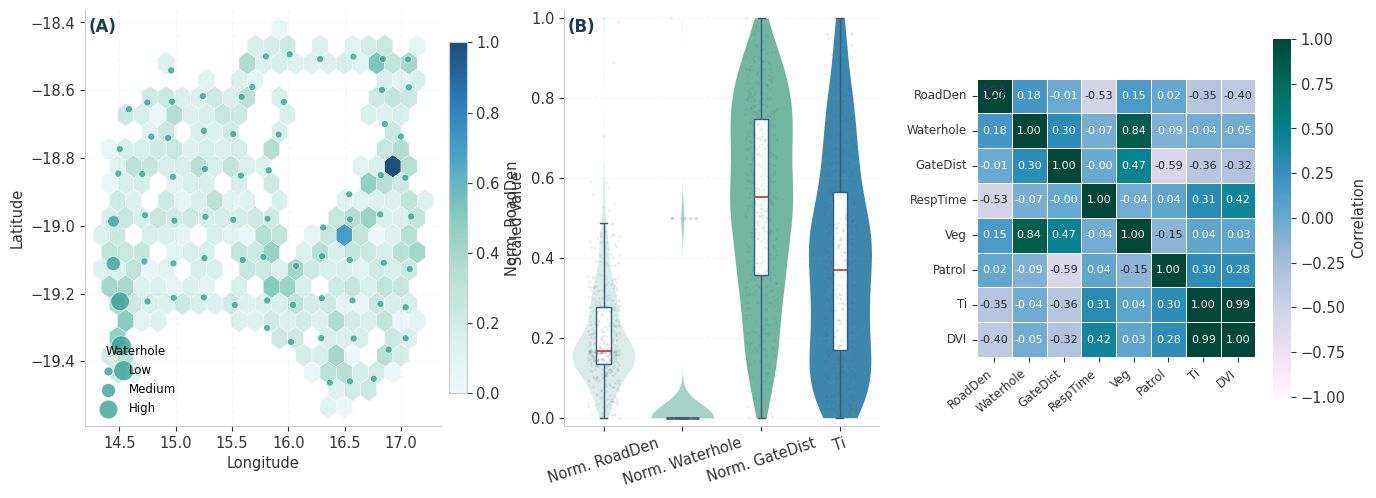

In [ ]:
# =========================
# Fig. 5 Data reprocessing
# Feature Engineering and Risk Structure
# Modified version:
# (A) aggregated spatial hexbin + waterhole overlay
# (B) distribution panel
# (C) correlation heatmap with short labels
# Optional inset: Etosha map image
# =========================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ---------- 1. Load data ----------
pre_df = pd.read_csv("/Users/hourosemary/IMMC/预处理.csv")
m1_df  = pd.read_csv("/Users/hourosemary/IMMC/Model1_R1_Final_Answers.csv")

# clean column names
pre_df.columns = pre_df.columns.str.strip()
m1_df.columns = m1_df.columns.str.strip()

# merge
df = pre_df.merge(
    m1_df[["Grid ID", "Ti", "DVI", "RRi", "Pt"]],
    on="Grid ID",
    how="inner"
)

# ---------- 2. Optional map image ----------
# Put your Etosha image path here. If not found, inset is skipped.
MAP_IMG_PATH = "/mnt/data/Etosha NP.jpg"
USE_MAP_INSET = os.path.exists(MAP_IMG_PATH)

# ---------- 3. Style ----------
plt.rcParams.update({
    "font.family": "DejaVu Sans",   # can switch to Arial
    "font.size": 10.5,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.edgecolor": "#CCCCCC",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# SCI cool-tone palettes
cmap_spatial = LinearSegmentedColormap.from_list(
    "sci_cool_bluegreen",
    ["#edf8fb", "#d7f0ea", "#b8e0d2", "#86cdbd", "#4ea6c8", "#2b7bba", "#1f4e79"]
)

dist_palette = ["#d7f0ea", "#9ed9c8", "#66c2a4", "#2b8cbe"]

# ---------- 4. Prepare variables ----------
# Panel B: use comparable scales
plot_df = df.copy()

# Min-max scale Ti only for distribution comparison
ti_min, ti_max = plot_df["Ti"].min(), plot_df["Ti"].max()
plot_df["Ti_scaled"] = (plot_df["Ti"] - ti_min) / (ti_max - ti_min + 1e-9)

# Long -> tidy for distribution panel
dist_vars = {
    "Norm. RoadDen": "Normalized Road Density",
    "Norm. Waterhole": "Normalized Waterhole Count 10km",
    "Norm. GateDist": "Normalized Distance to Gate km",
    "Ti": "Ti_scaled"
}

dist_long = pd.concat(
    [
        pd.DataFrame({
            "Variable": short_name,
            "Value": plot_df[col_name]
        })
        for short_name, col_name in dist_vars.items()
    ],
    axis=0
)

# Panel C: shorter labels
corr_map = {
    "RoadDen": "Normalized Road Density",
    "Waterhole": "Normalized Waterhole Count 10km",
    "GateDist": "Normalized Distance to Gate km",
    "RespTime": "Normalized Response Time Min",
    "Veg": "Vegetation Proxy",
    "Patrol": "Patrol Proxy",
    "Ti": "Ti",
    "DVI": "DVI"
}
corr_df = plot_df[[v for v in corr_map.values()]].copy()
corr_df.columns = list(corr_map.keys())
corr_mat = corr_df.corr()

# ---------- 5. Build figure ----------
fig = plt.figure(figsize=(16, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 0.95, 1.05], wspace=0.28)

# =========================
# Panel A: aggregated spatial hexbin
# =========================
ax1 = fig.add_subplot(gs[0, 0])

# hexbin of normalized road density
hb = ax1.hexbin(
    df["Longitude"],
    df["Latitude"],
    C=df["Normalized Road Density"],
    reduce_C_function=np.mean,
    gridsize=20,
    cmap=cmap_spatial,
    linewidths=0.25,
    edgecolors="white",
    mincnt=1
)

# overlay aggregated waterhole bubbles by coarse grid bins
xbins = np.linspace(df["Longitude"].min(), df["Longitude"].max(), 12)
ybins = np.linspace(df["Latitude"].min(), df["Latitude"].max(), 10)

tmp = df.copy()
tmp["xbin"] = pd.cut(tmp["Longitude"], bins=xbins, include_lowest=True)
tmp["ybin"] = pd.cut(tmp["Latitude"], bins=ybins, include_lowest=True)

agg = (
    tmp.groupby(["xbin", "ybin"], observed=False)
       .agg({
           "Longitude": "mean",
           "Latitude": "mean",
           "Waterhole Count 10km": "mean"
       })
       .dropna()
       .reset_index(drop=True)
)

if not agg.empty:
    w = agg["Waterhole Count 10km"]
    bubble_size = 25 + 180 * (w - w.min()) / (w.max() - w.min() + 1e-9)

    ax1.scatter(
        agg["Longitude"],
        agg["Latitude"],
        s=bubble_size,
        facecolor="#2a9d8f",
        edgecolor="white",
        linewidth=0.5,
        alpha=0.75
    )

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.10, linestyle="--")

cbar1 = plt.colorbar(hb, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("Norm. RoadDen")

# bubble legend
for s, lab in zip([40, 100, 180], ["Low", "Medium", "High"]):
    ax1.scatter([], [], s=s, facecolor="#2a9d8f", edgecolor="white",
                linewidth=0.5, alpha=0.75, label=lab)
ax1.legend(
    title="Waterhole",
    loc="lower left",
    frameon=False,
    fontsize=8.5,
    title_fontsize=8.5
)

# optional inset map
if USE_MAP_INSET:
    try:
        img = mpimg.imread(MAP_IMG_PATH)
        axins = inset_axes(ax1, width="30%", height="30%", loc="upper right", borderpad=0.9)
        axins.imshow(img)
        axins.set_xticks([])
        axins.set_yticks([])
        for spine in axins.spines.values():
            spine.set_edgecolor("#cccccc")
            spine.set_linewidth(0.8)
    except Exception as e:
        print(f"Map inset skipped: {e}")

ax1.text(0.01, 0.98, "(A)", transform=ax1.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel B: distribution structure
# =========================
ax2 = fig.add_subplot(gs[0, 1])

sns.violinplot(
    data=dist_long,
    x="Variable",
    y="Value",
    inner=None,
    cut=0,
    linewidth=0,
    palette=dist_palette,
    ax=ax2
)

sns.boxplot(
    data=dist_long,
    x="Variable",
    y="Value",
    width=0.18,
    showcaps=True,
    boxprops={"facecolor": "white", "edgecolor": "#355c7d", "linewidth": 1.0},
    whiskerprops={"color": "#355c7d", "linewidth": 1.0},
    medianprops={"color": "#c0392b", "linewidth": 1.2},
    showfliers=False,
    ax=ax2
)

sns.stripplot(
    data=dist_long,
    x="Variable",
    y="Value",
    color="#4a6178",
    alpha=0.12,
    size=1.8,
    jitter=0.20,
    ax=ax2
)

ax2.set_xlabel("")
ax2.set_ylabel("Scaled Value")
ax2.set_ylim(-0.02, 1.02)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="y", alpha=0.10, linestyle="--")
ax2.tick_params(axis="x", rotation=18)

ax2.text(0.01, 0.98, "(B)", transform=ax2.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel C: correlation heatmap
# =========================
ax3 = fig.add_subplot(gs[0, 2])

sns.heatmap(
    corr_mat,
    ax=ax3,
    cmap="PuBuGn",
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"shrink": 0.86, "label": "Correlation"},
    annot_kws={"fontsize": 8}
)

ax3.set_xticklabels(ax3.get_xticklabels(), rotation=40, ha="right")
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0)
ax3.tick_params(axis="both", labelsize=8.5)

ax3.text(0.01, 0.98, "(C)", transform=ax3.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# ---------- 6. Save ----------
plt.tight_layout()
plt.savefig("Fig5_Feature_Engineering_Risk_Structure.png", dpi=400, bbox_inches="tight")
plt.savefig("Fig5_Feature_Engineering_Risk_Structure.pdf", bbox_inches="tight")
plt.show()

/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_3565/1703117425.py:158: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_3565/1703117425.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


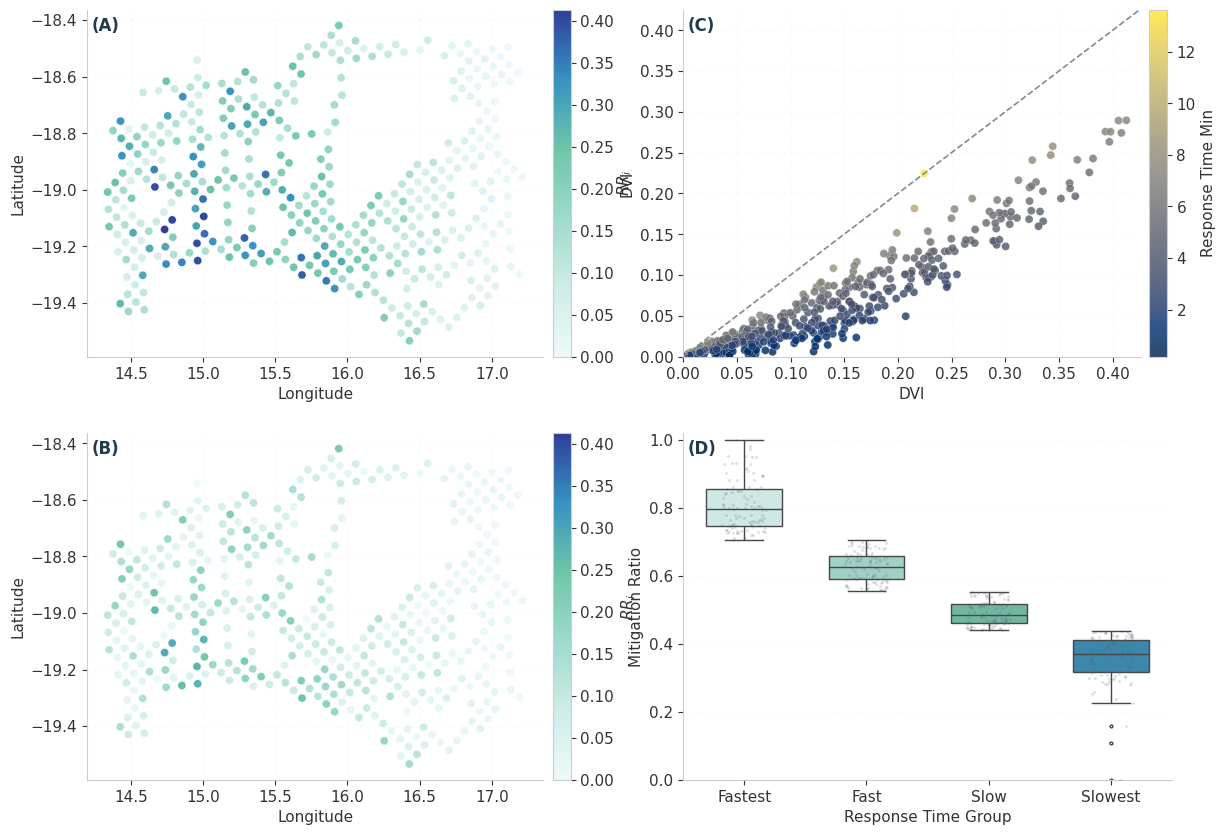

In [ ]:
# =========================
# Fig. 6（R1）
# Vulnerability, Residual Risk, and Protection Reduction
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# ---------- 1. Load data ----------
pre_df = pd.read_csv("/Users/hourosemary/IMMC/预处理.csv")
m1_df  = pd.read_csv("/Users/hourosemary/IMMC/Model1_R1_Final_Answers.csv")

df = pre_df.merge(
    m1_df[["Grid ID", "Ti", "DVI", "RRi", "Pt"]],
    on="Grid ID",
    how="inner"
)

# ---------- 2. Derived variables ----------
# Avoid division by zero
eps = 1e-9
df["Mitigation Ratio"] = 1 - df["RRi"] / (df["DVI"] + eps)
df["Mitigation Ratio"] = df["Mitigation Ratio"].clip(lower=0, upper=1)

# Response time quartiles
df["Response Group"] = pd.qcut(
    df["Response Time Min"],
    q=4,
    labels=["Fastest", "Fast", "Slow", "Slowest"]
)

# ---------- 3. Style ----------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.edgecolor": "#CCCCCC",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

cmap_spatial = LinearSegmentedColormap.from_list(
    "sci_cool_main",
    ["#edf8fb", "#ccece6", "#99d8c9", "#66c2a4", "#2b8cbe", "#253494"]
)

cmap_scatter = "cividis"
box_palette = ["#ccece6", "#99d8c9", "#66c2a4", "#2b8cbe"]

# Use same color range for DVI and RRi
common_vmin = 0
common_vmax = max(df["DVI"].max(), df["RRi"].max())

# ---------- 4. Build figure ----------
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.22)

# =========================
# Panel A: DVI spatial
# =========================
ax1 = fig.add_subplot(gs[0, 0])

sc1 = ax1.scatter(
    df["Longitude"], df["Latitude"],
    c=df["DVI"],
    s=34,
    cmap=cmap_spatial,
    vmin=common_vmin,
    vmax=common_vmax,
    alpha=0.95,
    edgecolor="white",
    linewidth=0.22
)

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.12, linestyle="--")
cbar1 = plt.colorbar(sc1, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("DVI")

ax1.text(0.01, 0.98, "(A)", transform=ax1.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel B: RRi spatial
# =========================
ax2 = fig.add_subplot(gs[1, 0])

sc2 = ax2.scatter(
    df["Longitude"], df["Latitude"],
    c=df["RRi"],
    s=34,
    cmap=cmap_spatial,
    vmin=common_vmin,
    vmax=common_vmax,
    alpha=0.95,
    edgecolor="white",
    linewidth=0.22
)

ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.12, linestyle="--")
cbar2 = plt.colorbar(sc2, ax=ax2, fraction=0.046, pad=0.02)
cbar2.set_label(r"$RR_i$")

ax2.text(0.01, 0.98, "(B)", transform=ax2.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel C: DVI vs RRi
# =========================
ax3 = fig.add_subplot(gs[0, 1])

sc3 = ax3.scatter(
    df["DVI"], df["RRi"],
    c=df["Response Time Min"],
    cmap=cmap_scatter,
    s=34,
    alpha=0.82,
    edgecolor="white",
    linewidth=0.22
)

# y=x reference line
lim_max = max(df["DVI"].max(), df["RRi"].max()) * 1.03
ax3.plot([0, lim_max], [0, lim_max], linestyle="--", color="#7f8c8d", linewidth=1.2)

ax3.set_xlim(0, lim_max)
ax3.set_ylim(0, lim_max)
ax3.set_xlabel("DVI")
ax3.set_ylabel(r"$RR_i$")
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.grid(alpha=0.12, linestyle="--")

cbar3 = plt.colorbar(sc3, ax=ax3, fraction=0.046, pad=0.02)
cbar3.set_label("Response Time Min")

ax3.text(0.01, 0.98, "(C)", transform=ax3.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel D: mitigation boxplot
# =========================
ax4 = fig.add_subplot(gs[1, 1])

sns.boxplot(
    data=df,
    x="Response Group",
    y="Mitigation Ratio",
    palette=box_palette,
    width=0.62,
    linewidth=1.0,
    fliersize=2,
    ax=ax4
)

sns.stripplot(
    data=df,
    x="Response Group",
    y="Mitigation Ratio",
    color="#4a6178",
    alpha=0.18,
    size=2.2,
    jitter=0.18,
    ax=ax4
)

ax4.set_xlabel("Response Time Group")
ax4.set_ylabel("Mitigation Ratio")
ax4.set_ylim(0, 1.02)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)
ax4.grid(axis="y", alpha=0.12, linestyle="--")

ax4.text(0.01, 0.98, "(D)", transform=ax4.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# ---------- 5. Save ----------
plt.tight_layout()
plt.savefig("Fig6_Vulnerability_ResidualRisk_ProtectionReduction.png", dpi=400, bbox_inches="tight")
plt.savefig("Fig6_Vulnerability_ResidualRisk_ProtectionReduction.pdf", bbox_inches="tight")
plt.show()

/var/folders/yn/md0jv9b56kv7z4k6cmpqgwdr0000gn/T/ipykernel_4870/2618415314.py:271: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


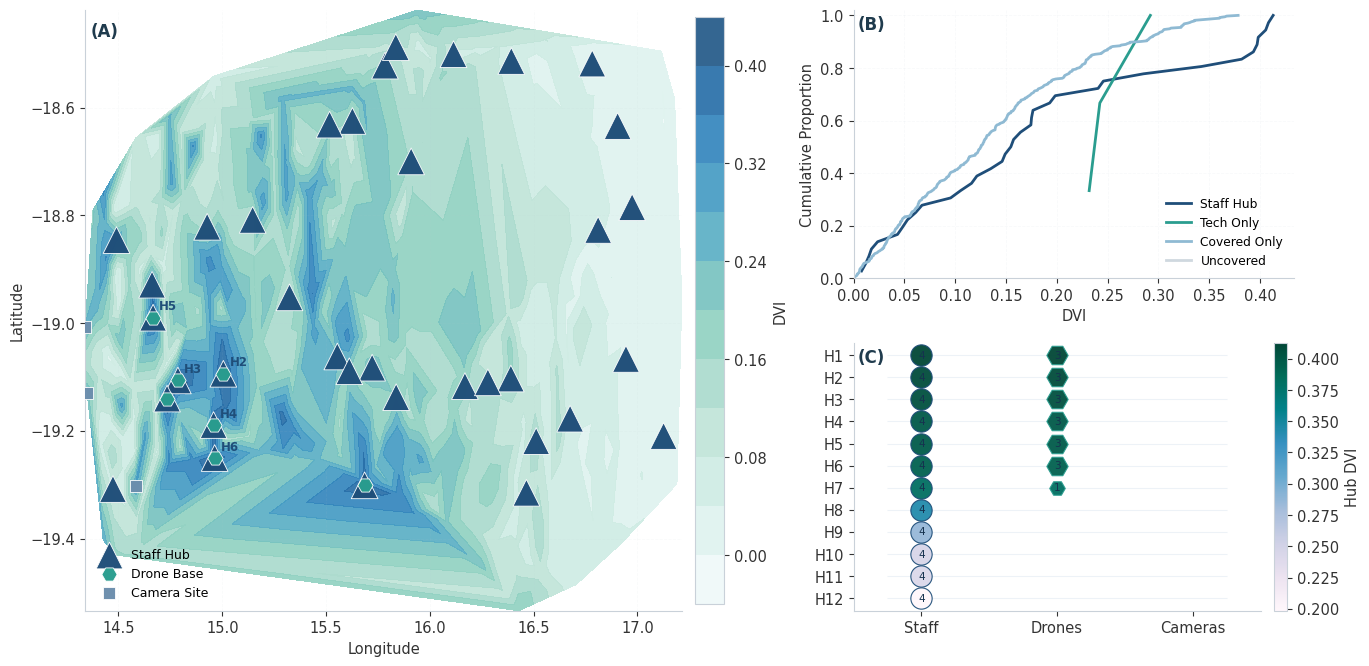

In [ ]:
# =========================
# R2 after MILP
# Fig. 7 
# Strategic Deployment Topology and Hub Synergy
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec

# ---------- 1. Load data ----------
df = pd.read_csv("/Users/hourosemary/IMMC/Model2_HighEnd_Deployment.csv")
df.columns = df.columns.str.strip()

# ---------- 2. Style ----------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.edgecolor": "#C9D1D9",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

cmap_dvi = LinearSegmentedColormap.from_list(
    "sci_cool_main",
    ["#f7fcfd", "#d7f0ea", "#b8e0d2", "#86cdbd", "#4ea6c8", "#2b7bba", "#1f4e79"]
)

STAFF_COLOR  = "#1f4e79"
DRONE_COLOR  = "#2a9d8f"
CAMERA_COLOR = "#6c8ead"

# ---------- 3. Derived variables ----------
df["HasTech"] = ((df["Drones"] > 0) | (df["Cameras"] > 0)).astype(int)

def classify_row(r):
    if r["Staff"] > 0:
        return "Staff Hub"
    elif (r["Drones"] > 0) or (r["Cameras"] > 0):
        return "Tech Only"
    elif r["Is_Covered"] > 0:
        return "Covered Only"
    else:
        return "Uncovered"

df["DeployType"] = df.apply(classify_row, axis=1)

order_types = ["Staff Hub", "Tech Only", "Covered Only", "Uncovered"]
palette_types = {
    "Staff Hub": STAFF_COLOR,
    "Tech Only": DRONE_COLOR,
    "Covered Only": "#8fbad3",
    "Uncovered": "#cfd8df"
}

hub_df = df[df["Staff"] > 0].copy()
hub_df = hub_df.sort_values(["Staff", "DVI"], ascending=[False, False]).reset_index(drop=True)
hub_df["HubLabel"] = [f"H{i+1}" for i in range(len(hub_df))]

# ---------- 4. Figure layout ----------
fig = plt.figure(figsize=(15.6, 7.8))
gs = gridspec.GridSpec(
    2, 2,
    width_ratios=[1.45, 1.0],
    height_ratios=[1.0, 1.0],
    wspace=0.24,
    hspace=0.24
)

# =========================
# Panel A: smoothed topology map
# =========================
ax1 = fig.add_subplot(gs[:, 0])

bg = ax1.tricontourf(
    df["Longitude"], df["Latitude"], df["DVI"],
    levels=10,
    cmap=cmap_dvi,
    alpha=0.92
)

# staff hubs
staff_df = df[df["Staff"] > 0]
staff_sizes = 90 + 70 * staff_df["Staff"]
ax1.scatter(
    staff_df["Longitude"], staff_df["Latitude"],
    s=staff_sizes,
    marker="^",
    color=STAFF_COLOR,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.98,
    zorder=5,
    label="Staff Hub"
)

# drone bases
drone_df = df[df["Drones"] > 0]
ax1.scatter(
    drone_df["Longitude"], drone_df["Latitude"],
    s=120,
    marker="H",
    color=DRONE_COLOR,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.98,
    zorder=6,
    label="Drone Base"
)

# camera sites
cam_df = df[df["Cameras"] > 0]
ax1.scatter(
    cam_df["Longitude"], cam_df["Latitude"],
    s=85,
    marker="s",
    color=CAMERA_COLOR,
    edgecolor="white",
    linewidth=0.6,
    alpha=0.98,
    zorder=6,
    label="Camera Site"
)

for _, row in hub_df.head(min(6, len(hub_df))).iterrows():
    ax1.text(
        row["Longitude"] + 0.03,
        row["Latitude"] + 0.015,
        row["HubLabel"],
        fontsize=8.5,
        color=STAFF_COLOR,
        weight="bold"
    )

ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(alpha=0.08, linestyle="--", linewidth=0.6, color="#BFC9D1")

cbar1 = plt.colorbar(bg, ax=ax1, fraction=0.046, pad=0.02)
cbar1.set_label("DVI")
cbar1.outline.set_edgecolor("#C9D1D9")

ax1.legend(loc="lower left", frameon=False, fontsize=9)
ax1.text(0.01, 0.98, "(A)", transform=ax1.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel B: ECDF of DVI by deployment type
# =========================
ax2 = fig.add_subplot(gs[0, 1])

for typ in order_types:
    sub = df.loc[df["DeployType"] == typ, "DVI"].dropna().sort_values().values
    if len(sub) == 0:
        continue
    y = np.arange(1, len(sub) + 1) / len(sub)
    ax2.plot(
        sub, y,
        linewidth=2.0,
        color=palette_types[typ],
        label=typ
    )

ax2.set_xlabel("DVI")
ax2.set_ylabel("Cumulative Proportion")
ax2.set_xlim(left=0)
ax2.set_ylim(0, 1.02)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(alpha=0.10, linestyle="--", linewidth=0.6, color="#BFC9D1")
ax2.legend(frameon=False, fontsize=8.8, loc="lower right")

ax2.text(0.01, 0.98, "(B)", transform=ax2.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

# =========================
# Panel C: Hub composition matrix (sparser)
# =========================
ax3 = fig.add_subplot(gs[1, 1])

if len(hub_df) > 0:
    plot_hubs = (
        hub_df.sort_values(["Staff", "DVI"], ascending=[False, False])
              .head(12)
              .reset_index(drop=True)
    )

    y_positions = np.arange(len(plot_hubs)) * 1.4
    norm = plt.Normalize(vmin=plot_hubs["DVI"].min(), vmax=plot_hubs["DVI"].max())
    cmap = plt.cm.PuBuGn
    colors = cmap(norm(plot_hubs["DVI"]))

    for y in y_positions:
        ax3.hlines(y, xmin=-0.25, xmax=2.25, color="#edf2f7", linewidth=0.8, zorder=0)

    for idx, row in plot_hubs.iterrows():
        y = y_positions[len(plot_hubs) - 1 - idx]
        color = colors[idx]

        if row["Staff"] > 0:
            ax3.scatter(
                0, y,
                s=55 + 45 * row["Staff"],
                color=color,
                edgecolor=STAFF_COLOR,
                linewidth=0.8,
                alpha=0.95,
                marker="o",
                zorder=3
            )
            ax3.text(0, y, f"{int(row['Staff'])}",
                     ha="center", va="center", fontsize=7.5, color="#16324f")

        if row["Drones"] > 0:
            ax3.scatter(
                1, y,
                s=70 + 55 * row["Drones"],
                color=color,
                edgecolor=DRONE_COLOR,
                linewidth=0.8,
                alpha=0.95,
                marker="H",
                zorder=3
            )
            ax3.text(1, y, f"{int(row['Drones'])}",
                     ha="center", va="center", fontsize=7.5, color="#16324f")

        if row["Cameras"] > 0:
            ax3.scatter(
                2, y,
                s=65 + 50 * row["Cameras"],
                color=color,
                edgecolor=CAMERA_COLOR,
                linewidth=0.8,
                alpha=0.95,
                marker="s",
                zorder=3
            )
            ax3.text(2, y, f"{int(row['Cameras'])}",
                     ha="center", va="center", fontsize=7.5, color="#16324f")

    ax3.set_xticks([0, 1, 2])
    ax3.set_xticklabels(["Staff", "Drones", "Cameras"])
    ax3.set_yticks(y_positions)
    ax3.set_yticklabels(plot_hubs["HubLabel"][::-1])

    ax3.set_xlim(-0.5, 2.5)
    ax3.set_ylim(-0.8, y_positions[-1] + 0.8)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)
    ax3.spines["left"].set_color("#C9D1D9")
    ax3.spines["bottom"].set_color("#C9D1D9")
    ax3.grid(False)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar3 = plt.colorbar(sm, ax=ax3, fraction=0.046, pad=0.03)
    cbar3.set_label("Hub DVI")
    cbar3.outline.set_edgecolor("#C9D1D9")

ax3.text(0.01, 0.98, "(C)", transform=ax3.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color="#1f3b4d")

plt.tight_layout()
plt.savefig("Fig7_Strategic_Deployment_Topology_Synergy_final.png", dpi=450, bbox_inches="tight")
plt.savefig("Fig7_Strategic_Deployment_Topology_Synergy_final.pdf", bbox_inches="tight")
plt.show()

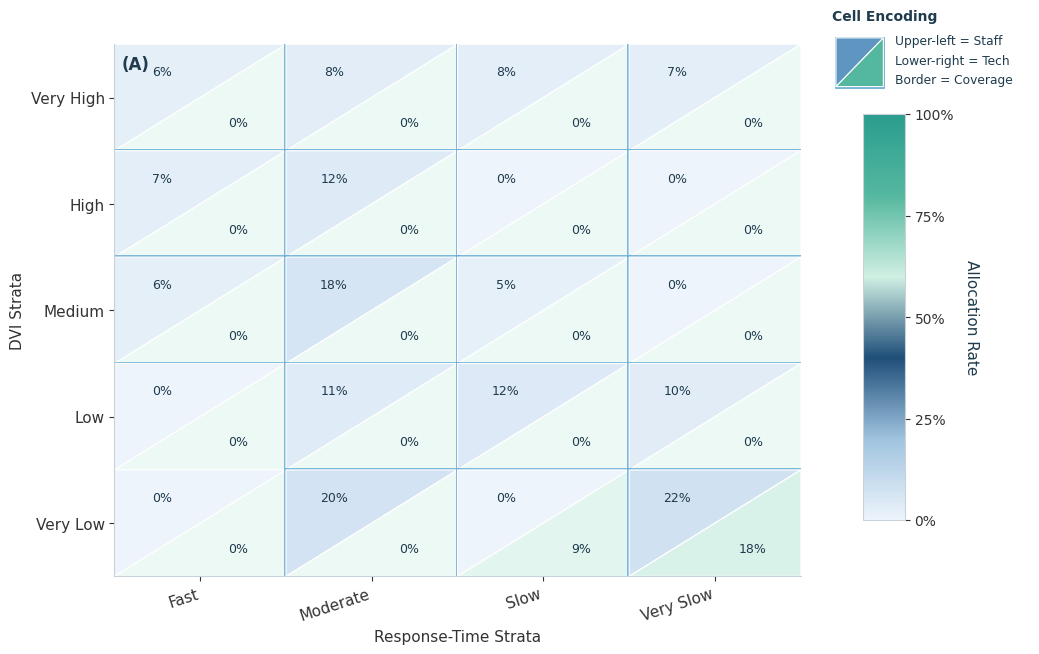

In [8]:
# =========================
# Fig. 8 (Complete Revised Version)
# Split-Cell Allocation Matrix over Risk–Response Strata
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# ===============================
# 1. Load data
# ===============================
df = pd.read_csv("/Users/hourosemary/IMMC/Model2_HighEnd_Deployment.csv")
df.columns = df.columns.str.strip()

# ===============================
# 2. Derived indicators
# ===============================
df["HasStaff"] = (df["Staff"] > 0).astype(int)
df["HasTech"] = ((df["Drones"] > 0) | (df["Cameras"] > 0)).astype(int)
df["HasCoverage"] = (df["Is_Covered"] > 0).astype(int)

# ===============================
# 3. Build strata (stable labels)
# ===============================
df["RespBin"] = pd.qcut(
    df["Response Time Min"],
    q=4,
    labels=["Fast", "Moderate", "Slow", "Very Slow"]
)

df["DVIBin"] = pd.qcut(
    df["DVI"],
    q=5,
    labels=["Very High", "High", "Medium", "Low", "Very Low"]
)

# ===============================
# 4. Build rate matrices
# ===============================
def make_rate_matrix(col):
    mat = (
        df.groupby(["DVIBin", "RespBin"], observed=False)[col]
          .mean()
          .unstack()
    )
    mat = mat.reindex(
        index=["Very High", "High", "Medium", "Low", "Very Low"],
        columns=["Fast", "Moderate", "Slow", "Very Slow"]
    )
    return mat.fillna(0)

staff_mat = make_rate_matrix("HasStaff")
tech_mat  = make_rate_matrix("HasTech")
cov_mat   = make_rate_matrix("HasCoverage")

# ===============================
# 5. Style
# ===============================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.edgecolor": "#C9D1D9",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

# unified cool-tone palettes
staff_cmap = LinearSegmentedColormap.from_list(
    "staff_blue",
    ["#edf4fb", "#cddff1", "#9fc3df", "#5f97c2", "#1f4e79"]
)

tech_cmap = LinearSegmentedColormap.from_list(
    "tech_teal",
    ["#edf9f5", "#d0efe3", "#9ed9c8", "#55b89f", "#2a9d8f"]
)

# right-side visual legend strip
legend_cmap = LinearSegmentedColormap.from_list(
    "legend_mix",
    ["#edf4fb", "#9fc3df", "#1f4e79", "#d0efe3", "#55b89f", "#2a9d8f"]
)

staff_norm = Normalize(vmin=0, vmax=1)
tech_norm  = Normalize(vmin=0, vmax=1)

grid_edge = "#d7dee5"
text_dark = "#1f3b4d"

# ===============================
# 6. Figure layout
# ===============================
fig = plt.figure(figsize=(10.4, 7.0))

# main matrix
ax = fig.add_axes([0.10, 0.12, 0.66, 0.76])

n_rows, n_cols = staff_mat.shape

# ===============================
# 7. Draw split-cell matrix
# ===============================
for i in range(n_rows):
    for j in range(n_cols):
        x0, y0 = j, n_rows - 1 - i
        x1, y1 = j + 1, n_rows - i

        staff_val = float(staff_mat.iloc[i, j])
        tech_val  = float(tech_mat.iloc[i, j])
        cov_val   = float(cov_mat.iloc[i, j])

        # border encodes coverage
        border_w = 0.8 + 2.6 * cov_val
        border_c = "#6baed6" if cov_val > 0 else "#e1e8ef"

        # base cell
        rect = Rectangle(
            (x0, y0), 1, 1,
            facecolor="white",
            edgecolor=border_c,
            linewidth=border_w
        )
        ax.add_patch(rect)

        # upper-left triangle = staff
        tri_staff = Polygon(
            [[x0, y1], [x0, y0], [x1, y1]],
            closed=True,
            facecolor=staff_cmap(staff_norm(staff_val)),
            edgecolor="white",
            linewidth=0.9
        )
        ax.add_patch(tri_staff)

        # lower-right triangle = tech
        tri_tech = Polygon(
            [[x1, y0], [x1, y1], [x0, y0]],
            closed=True,
            facecolor=tech_cmap(tech_norm(tech_val)),
            edgecolor="white",
            linewidth=0.9
        )
        ax.add_patch(tri_tech)

        # percentage labels
        staff_pct = int(round(staff_val * 100))
        tech_pct  = int(round(tech_val * 100))

        ax.text(
            x0 + 0.28, y0 + 0.74,
            f"{staff_pct}%",
            ha="center", va="center",
            fontsize=9,
            color="white" if staff_val > 0.45 else text_dark,
            fontweight="bold" if staff_val > 0.70 else "normal"
        )

        ax.text(
            x0 + 0.72, y0 + 0.26,
            f"{tech_pct}%",
            ha="center", va="center",
            fontsize=9,
            color="white" if tech_val > 0.45 else text_dark,
            fontweight="bold" if tech_val > 0.70 else "normal"
        )

# ===============================
# 8. Axis formatting
# ===============================
ax.set_xlim(0, n_cols)
ax.set_ylim(0, n_rows)

ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_xticklabels(["Fast", "Moderate", "Slow", "Very Slow"], rotation=18, ha="right")

ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_yticklabels(["Very Low", "Low", "Medium", "High", "Very High"], rotation=0)

ax.set_xlabel("Response-Time Strata")
ax.set_ylabel("DVI Strata")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#C9D1D9")
ax.spines["bottom"].set_color("#C9D1D9")

ax.text(
    0.01, 0.98, "(A)",
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=12, fontweight="bold", color=text_dark
)

# ===============================
# 9. Single vertical legend strip
# ===============================
cax = fig.add_axes([0.82, 0.20, 0.04, 0.58])
sm = ScalarMappable(norm=Normalize(0, 1), cmap=legend_cmap)
sm.set_array([])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_ticks([0, 0.25, 0.50, 0.75, 1.00])
cbar.set_ticklabels(["0%", "25%", "50%", "75%", "100%"])
cbar.ax.tick_params(labelsize=10, colors="#333333")
cbar.outline.set_edgecolor("#C9D1D9")
cbar.set_label("Allocation Rate", rotation=270, labelpad=18, color=text_dark)

# ===============================
# 10. Cell encoding explainer
# ===============================
leg_ax = fig.add_axes([0.79, 0.81, 0.19, 0.12])
leg_ax.axis("off")
leg_ax.text(0.0, 1.0, "Cell Encoding", fontsize=10, color=text_dark, weight="bold", va="top")

ex_x, ex_y, w, h = 0.02, 0.08, 0.24, 0.58
leg_ax.add_patch(Rectangle((ex_x, ex_y), w, h, facecolor="white", edgecolor="#6baed6", linewidth=2.0))
leg_ax.add_patch(Polygon(
    [[ex_x, ex_y+h], [ex_x, ex_y], [ex_x+w, ex_y+h]],
    closed=True, facecolor=staff_cmap(0.75), edgecolor="white", linewidth=0.8
))
leg_ax.add_patch(Polygon(
    [[ex_x+w, ex_y], [ex_x+w, ex_y+h], [ex_x, ex_y]],
    closed=True, facecolor=tech_cmap(0.75), edgecolor="white", linewidth=0.8
))

leg_ax.text(0.32, 0.62, "Upper-left = Staff", fontsize=8.8, color=text_dark, va="center")
leg_ax.text(0.32, 0.39, "Lower-right = Tech", fontsize=8.8, color=text_dark, va="center")
leg_ax.text(0.32, 0.16, "Border = Coverage", fontsize=8.8, color=text_dark, va="center")

# ===============================
# 11. Save
# ===============================
plt.savefig("Fig8_Split_Cell_Allocation_Matrix_complete.png", dpi=450, bbox_inches="tight")
plt.savefig("Fig8_Split_Cell_Allocation_Matrix_complete.pdf", bbox_inches="tight")
plt.show()

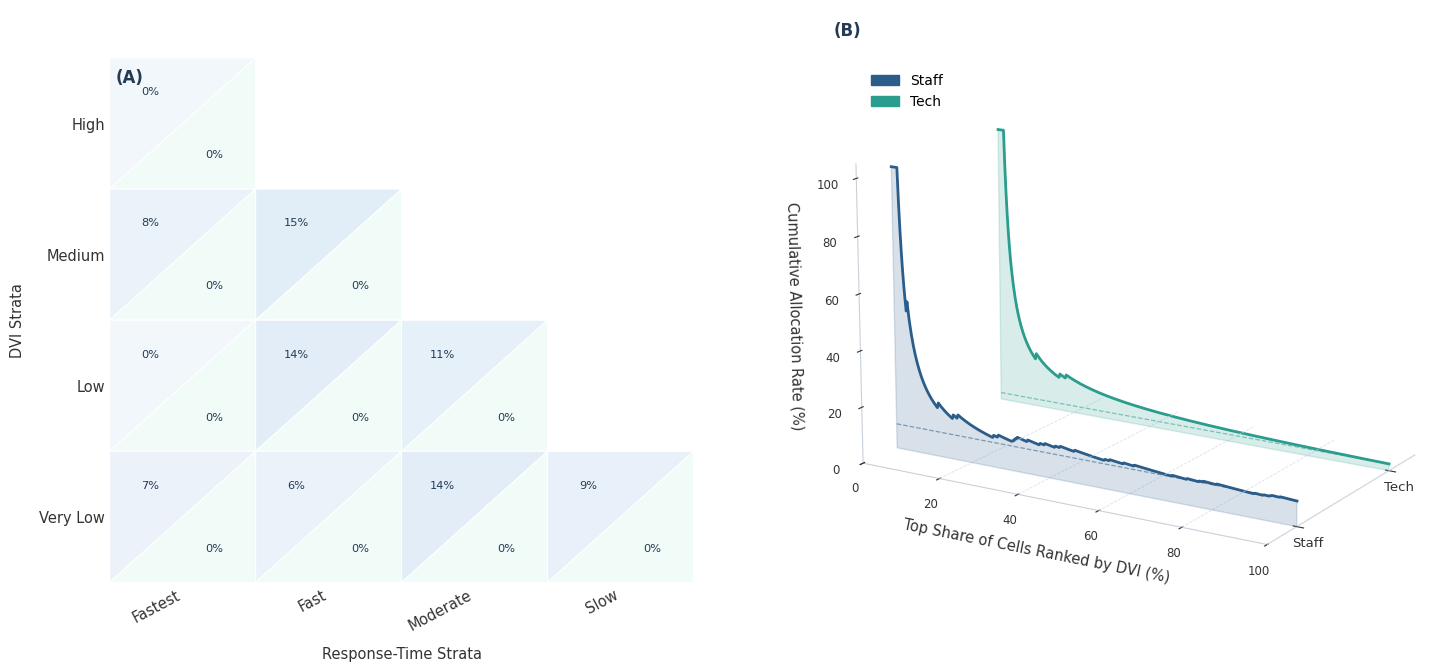

In [17]:
# =========================
# Fig. 8 (Final Revised)
# Allocation Structure and Risk-Concentration Patterns
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import PolyCollection
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ===============================
# 1. Load data
# ===============================
df = pd.read_csv("/Users/hourosemary/IMMC/Model2_HighEnd_Deployment.csv")
df.columns = df.columns.str.strip()

# ===============================
# 2. Derived indicators
# ===============================
df["HasStaff"] = (df["Staff"] > 0).astype(int)
df["HasTech"] = ((df["Drones"] > 0) | (df["Cameras"] > 0)).astype(int)
df["HasCoverage"] = (df["Is_Covered"] > 0).astype(int)

# ===============================
# 3. Build 5x5 strata
# ===============================
df["DVI_rank_bin"] = pd.qcut(
    df["DVI"].rank(method="first"),
    q=5,
    labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

df["Resp_rank_bin"] = pd.qcut(
    df["Response Time Min"].rank(method="first"),
    q=5,
    labels=["Fastest", "Fast", "Moderate", "Slow", "Slowest"]
)

dvi_order  = ["Very High", "High", "Medium", "Low", "Very Low"]
resp_order = ["Fastest", "Fast", "Moderate", "Slow", "Slowest"]

df["DVIBin"] = pd.Categorical(df["DVI_rank_bin"], categories=dvi_order, ordered=True)
df["RespBin"] = pd.Categorical(df["Resp_rank_bin"], categories=resp_order, ordered=True)

def make_rate_matrix(col):
    mat = (
        df.groupby(["DVIBin", "RespBin"], observed=False)[col]
          .mean()
          .unstack()
    )
    mat = mat.reindex(index=dvi_order, columns=resp_order)
    return mat.fillna(0)

staff_mat = make_rate_matrix("HasStaff")
tech_mat  = make_rate_matrix("HasTech")

# ===============================
# 4. Cumulative curves for waterfall
# ===============================
df_sorted = df.sort_values("DVI", ascending=False).reset_index(drop=True)
n = len(df_sorted)
x = np.arange(1, n + 1) / n * 100

y_staff = df_sorted["HasStaff"].cumsum() / np.arange(1, n + 1) * 100
y_tech  = df_sorted["HasTech"].cumsum() / np.arange(1, n + 1) * 100

bench_staff = df_sorted["HasStaff"].mean() * 100
bench_tech  = df_sorted["HasTech"].mean() * 100

# ===============================
# 5. Style
# ===============================
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10.5,
    "axes.labelcolor": "#333333",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.edgecolor": "#C9D1D9",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white"
})

staff_cmap = LinearSegmentedColormap.from_list(
    "staff_blue",
    ["#f2f7fc", "#d6e6f4", "#a9c7e1", "#6d9fc9", "#2b5d8a"]
)

tech_cmap = LinearSegmentedColormap.from_list(
    "tech_teal",
    ["#f1fbf8", "#d7f1e9", "#a7ddd2", "#67bfae", "#2a9d8f"]
)

cover_cmap = LinearSegmentedColormap.from_list(
    "cover_navy",
    ["#eef4fb", "#d5e3f1", "#a8c3db", "#6e9cc2", "#2b5d8a"]
)

staff_norm = Normalize(0, 1)
tech_norm  = Normalize(0, 1)
cover_norm = Normalize(0, 1)

colors = {
    "Staff": "#2b5d8a",
    "Tech": "#2a9d8f"
}

text_dark = "#243b53"

# ===============================
# 6. Figure layout
# ===============================
fig = plt.figure(figsize=(14.6, 6.9))

# A图稍向左靠，B图原位四周扩展（放大）
ax1 = fig.add_axes([0.05, 0.12, 0.40, 0.76])
ax2 = fig.add_axes([0.52, 0.05, 0.46, 0.90], projection="3d")

# ===============================
# 7. Left panel: triangular split-cell matrix
# ===============================
nmat = 5

for i in range(nmat):
    for j in range(nmat):
        # 核心修改：只绘制下三角部分，去除对角线和上三角所有的灰色空白框
        if j >= i:
            continue

        x0, y0 = j, nmat - 1 - i
        x1, y1 = j + 1, nmat - i

        staff_val = float(staff_mat.iloc[i, j])
        tech_val  = float(tech_mat.iloc[i, j])

        # 绘制职员三角形
        tri_staff = Polygon(
            [[x0, y1], [x0, y0], [x1, y1]],
            closed=True,
            facecolor=staff_cmap(staff_norm(staff_val)),
            edgecolor="white",
            linewidth=0.8
        )
        ax1.add_patch(tri_staff)

        # 绘制技术三角形
        tri_tech = Polygon(
            [[x1, y0], [x1, y1], [x0, y0]],
            closed=True,
            facecolor=tech_cmap(tech_norm(tech_val)),
            edgecolor="white",
            linewidth=0.8
        )
        ax1.add_patch(tri_tech)

        # 文本标注
        ax1.text(
            x0 + 0.28, y0 + 0.74,
            f"{int(round(staff_val * 100))}%",
            ha="center", va="center",
            fontsize=8.2,
            color="white" if staff_val > 0.48 else text_dark,
            fontweight="bold" if staff_val > 0.72 else "normal"
        )

        ax1.text(
            x0 + 0.72, y0 + 0.26,
            f"{int(round(tech_val * 100))}%",
            ha="center", va="center",
            fontsize=8.2,
            color="white" if tech_val > 0.48 else text_dark,
            fontweight="bold" if tech_val > 0.72 else "normal"
        )

# 核心修改：去除 Very High 和 Slowest，网格数从 5 变为 4
ax1.set_xlim(0, nmat - 1)
ax1.set_ylim(0, nmat - 1)

# 核心修改：截断最后一个标签 (切除 Slowest)
ax1.set_xticks(np.arange(nmat - 1) + 0.5)
ax1.set_xticklabels(resp_order[:-1], rotation=28, ha="right")

# 核心修改：截断最后一个标签 (由于原本是倒序排列的，去掉倒序后的最后一个，即去除了 Very High)
ax1.set_yticks(np.arange(nmat - 1) + 0.5)
ax1.set_yticklabels(dvi_order[::-1][:-1], rotation=0)

ax1.set_xlabel("Response-Time Strata", labelpad=10)
ax1.set_ylabel("DVI Strata", labelpad=10)

for side in ["top", "right", "left", "bottom"]:
    ax1.spines[side].set_visible(False)

ax1.tick_params(length=0)

ax1.text(0.01, 0.98, "(A)", transform=ax1.transAxes,
         ha="left", va="top", fontsize=12, fontweight="bold", color=text_dark)


# ===============================
# 8. Right panel: 3D waterfall (Staff + Tech only)
# ===============================
surface_labels = ["Staff", "Tech"]
surface_y_data = [y_staff, y_tech]
surface_colors = [colors["Staff"], colors["Tech"]]

verts = []
for y_data in surface_y_data:
    padded_x = np.r_[x[0], x, x[-1]]
    padded_y = np.r_[0, y_data, 0]
    verts.append(list(zip(padded_x, padded_y)))

poly = PolyCollection(
    verts,
    facecolors=surface_colors,
    alpha=0.18,
    edgecolors=surface_colors,
    linewidths=1.0
)
ax2.add_collection3d(poly, zs=np.arange(len(surface_y_data)), zdir='x')

for i, y_data in enumerate(surface_y_data):
    ax2.plot(x, y_data, zs=i, zdir='x', color=surface_colors[i], linewidth=2.0)

benchmarks = [bench_staff, bench_tech]
for i, b in enumerate(benchmarks):
    ax2.plot([x.min(), x.max()], [b, b], zs=i, zdir='x',
             color=surface_colors[i], linestyle='--', linewidth=0.9, alpha=0.55)

ax2.set_xlabel("")
ax2.set_ylabel("Top Share of Cells Ranked by DVI (%)", fontsize=10.5, labelpad=8)
ax2.set_zlabel("Cumulative Allocation Rate (%)", fontsize=10.5, labelpad=6)

ax2.set_xlim(-0.3, 1.3)
ax2.set_ylim(100, 0)
ax2.set_zlim(0, 105)

ax2.set_xticks([0, 1])
ax2.set_xticklabels(["Staff", "Tech"], fontsize=9.5)

ax2.tick_params(axis='x', pad=-2)
ax2.tick_params(axis='y', labelsize=8.5)
ax2.tick_params(axis='z', labelsize=8.5)

ax2.view_init(elev=16, azim=-149)

ax2.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))

ax2.xaxis.pane.set_edgecolor((1.0, 1.0, 1.0, 0.0))
ax2.yaxis.pane.set_edgecolor((1.0, 1.0, 1.0, 0.0))
ax2.zaxis.pane.set_edgecolor((1.0, 1.0, 1.0, 0.0))

ax2.set_box_aspect((10, 15, 10))
ax2.grid(False)

zmin, zmax = ax2.get_zlim()
xmin, xmax = ax2.get_xlim()
ymin_back, ymax_front = ax2.get_ylim()
yticks = ax2.get_yticks()

for y_pos in yticks[1:]:
    ax2.plot([xmin, xmax], [y_pos, y_pos], [zmin, zmin],
             color='#d9e2ec', linestyle='--', linewidth=0.6)

ax2.text2D(0.02, 0.98, "(B)", transform=ax2.transAxes,
           ha="left", va="top", fontsize=12, fontweight="bold", color=text_dark)

# 核心修改：图例移动到 B 图内的左下/上方留白处
legend_patches = [
    mpatches.Patch(color=colors["Staff"], label="Staff"),
    mpatches.Patch(color=colors["Tech"], label="Tech"),
]
ax2.legend(
    handles=legend_patches,
    loc='lower left',
    bbox_to_anchor=(0.06, 0.82),
    frameon=False,
    fontsize=10
)

# ===============================
# 9. Save
# ===============================
plt.savefig("Fig8_Combined_Structure_and_RiskConcentration_final.png", dpi=450, bbox_inches="tight")
plt.savefig("Fig8_Combined_Structure_and_RiskConcentration_final.pdf", bbox_inches="tight")
plt.show()